In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

sys.path.append("..")
from utils.similarity import (
    get_feature_columns,
    build_feature_matrix,
    z_score_normalize,
    cosine_similarity_matrix,
    pairwise_distance_matrix,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
DATA_PATH = Path("../data/extracted/rhythm_features.parquet")
rhythm_df = pd.read_parquet(DATA_PATH)
rhythm_df.shape


(109089, 41)

In [3]:
feature_cols = get_feature_columns(rhythm_df)
X = build_feature_matrix(rhythm_df, feature_cols)
X_norm = z_score_normalize(X)
X_norm.shape


(109089, 34)

In [4]:
MAX_SEGMENTS = 1500

if X_norm.shape[0] > MAX_SEGMENTS:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(X_norm.shape[0], size=MAX_SEGMENTS, replace=False)
    sample_idx.sort()
else:
    sample_idx = np.arange(X_norm.shape[0])

X_sample = X_norm[sample_idx]
meta_sample = rhythm_df.iloc[sample_idx].reset_index(drop=True)
X_sample.shape


(1500, 34)

In [5]:
segment_cos_sim = cosine_similarity_matrix(X_sample)
segment_cos_sim.shape


(1500, 1500)

In [6]:
segment_dist = pairwise_distance_matrix(X_sample, metric="euclidean")
segment_dist.shape


(1500, 1500)

In [7]:
genre_labels = meta_sample["genre"].values
same_genre_mask = genre_labels[:, None] == genre_labels[None, :]
np.fill_diagonal(same_genre_mask, False)

triu_idx = np.triu_indices_from(segment_cos_sim, k=1)
sim_values = segment_cos_sim[triu_idx]
same_genre_pairs = same_genre_mask[triu_idx]

within_genre_sim = sim_values[same_genre_pairs]
across_genre_sim = sim_values[~same_genre_pairs]

within_genre_sim.mean(), across_genre_sim.mean()


(np.float64(0.07374172271348423), np.float64(0.0031511379956834546))

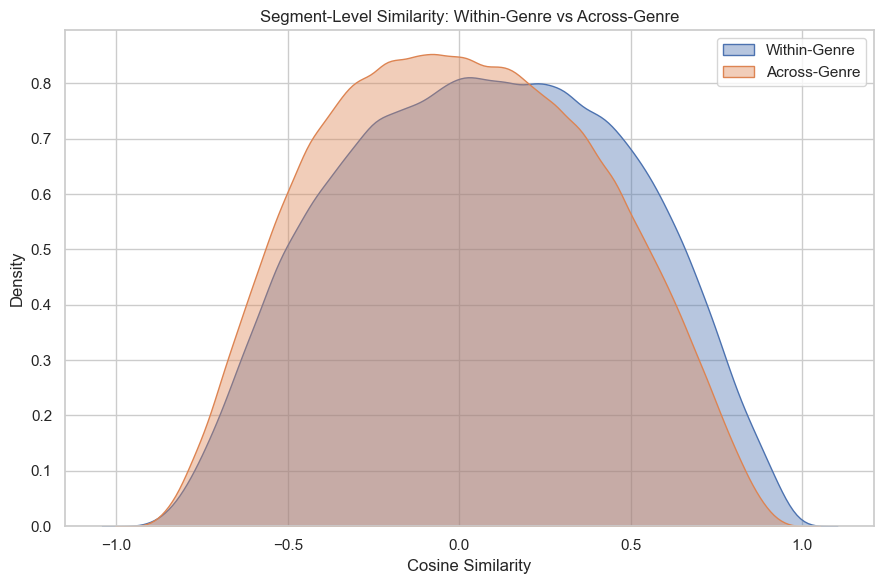

In [8]:
plt.figure(figsize=(9, 6))
sns.kdeplot(within_genre_sim, label="Within-Genre", fill=True, alpha=0.4)
sns.kdeplot(across_genre_sim, label="Across-Genre", fill=True, alpha=0.4)
plt.xlabel("Cosine Similarity")
plt.title("Segment-Level Similarity: Within-Genre vs Across-Genre")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
n_neighbors = 6
nn_model = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
nn_model.fit(X_sample)
distances, indices = nn_model.kneighbors(X_sample)


In [10]:
def neighbor_genre_agreement(indices: np.ndarray, labels: np.ndarray) -> np.ndarray:
    agreement = np.zeros(len(labels))
    for i in range(len(labels)):
        neighbor_idx = indices[i, 1:]
        neighbor_labels = labels[neighbor_idx]
        agreement[i] = np.mean(neighbor_labels == labels[i])
    return agreement

genre_agreement = neighbor_genre_agreement(indices, genre_labels)
meta_sample["neighbor_genre_agreement"] = genre_agreement
meta_sample.groupby("genre")["neighbor_genre_agreement"].mean().sort_values(ascending=False)


genre
Sufi            0.431655
Maand           0.348315
Uttarakhandi    0.341573
Sohar           0.337647
Kajri           0.326937
Gidha           0.286047
Bhatiali        0.277465
Bauls           0.174074
Name: neighbor_genre_agreement, dtype: float64

C:\Users\ankit\AppData\Local\Temp\ipykernel_25604\3921879375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agreement_by_genre.values, y=agreement_by_genre.index, palette="crest")


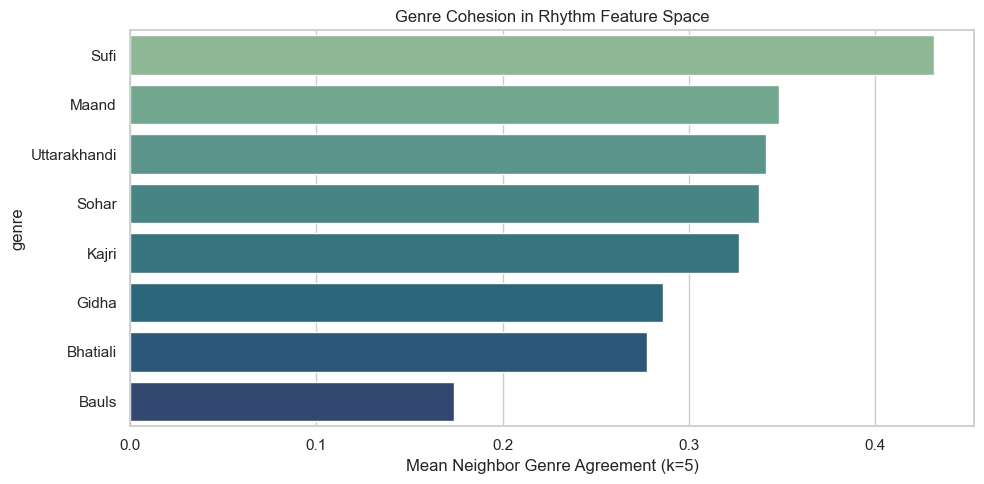

In [11]:
plt.figure(figsize=(10, 5))
agreement_by_genre = meta_sample.groupby("genre")["neighbor_genre_agreement"].mean().sort_values(ascending=False)
sns.barplot(x=agreement_by_genre.values, y=agreement_by_genre.index, palette="crest")
plt.xlabel(f"Mean Neighbor Genre Agreement (k={n_neighbors - 1})")
plt.title("Genre Cohesion in Rhythm Feature Space")
plt.tight_layout()
plt.show()


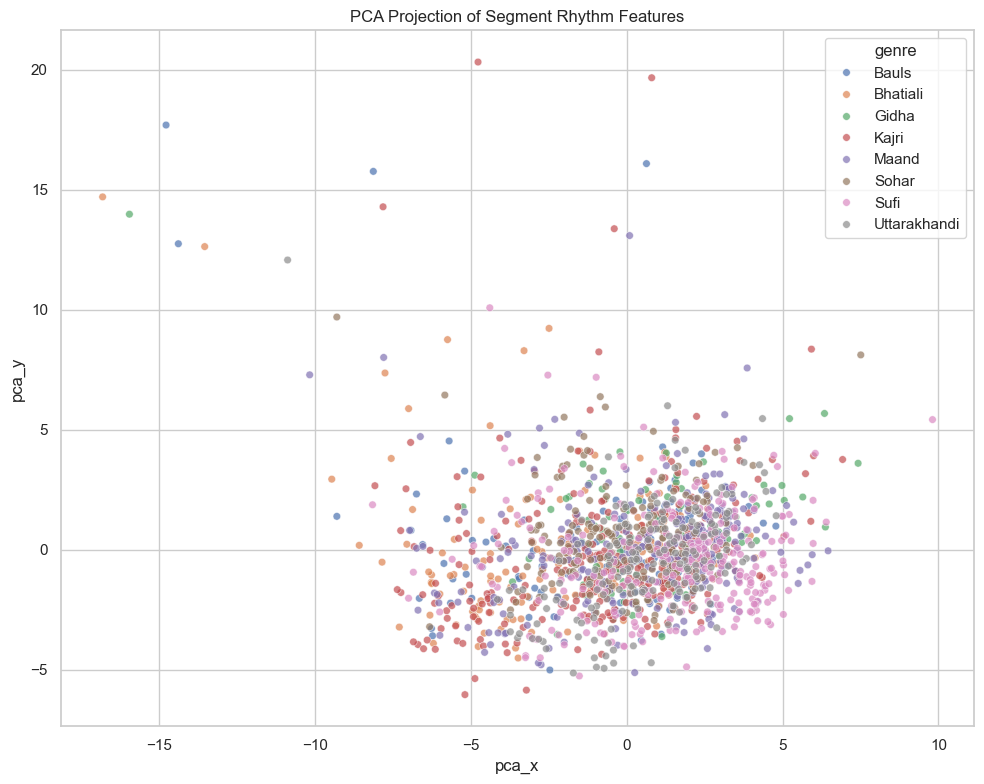

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_sample)

plot_df = meta_sample.copy()
plot_df["pca_x"] = pca_coords[:, 0]
plot_df["pca_y"] = pca_coords[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x="pca_x", y="pca_y", hue="genre", alpha=0.7, s=30)
plt.title("PCA Projection of Segment Rhythm Features")
plt.tight_layout()
plt.show()


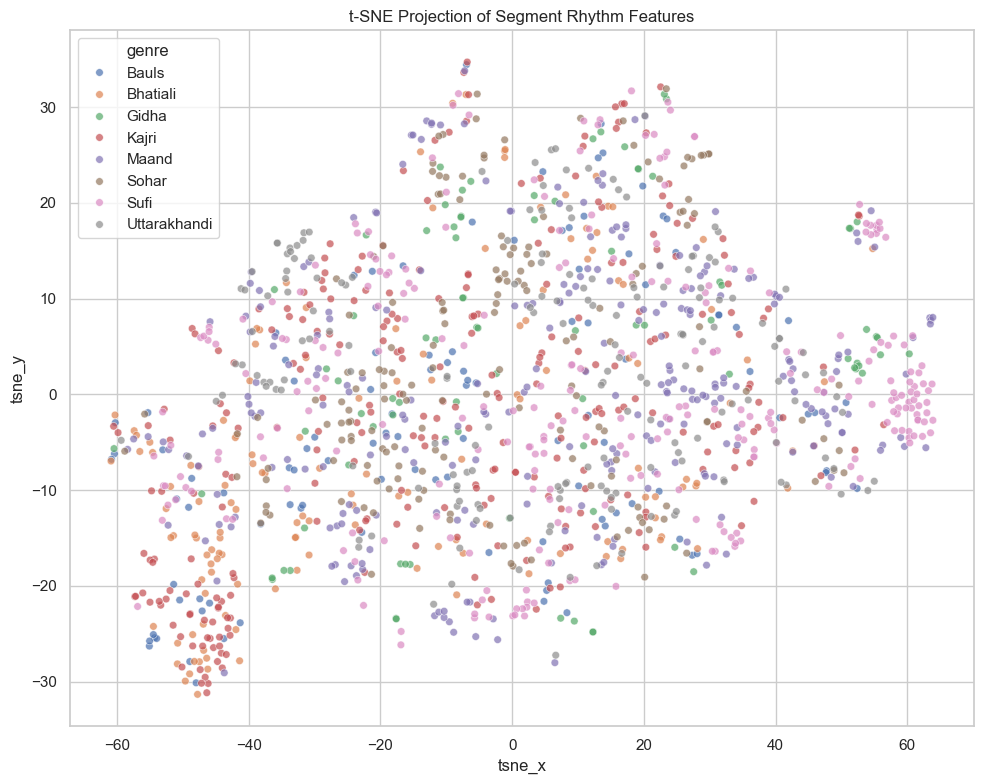

In [13]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
tsne_coords = tsne.fit_transform(X_sample)

plot_df["tsne_x"] = tsne_coords[:, 0]
plot_df["tsne_y"] = tsne_coords[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x="tsne_x", y="tsne_y", hue="genre", alpha=0.7, s=30)
plt.title("t-SNE Projection of Segment Rhythm Features")
plt.tight_layout()
plt.show()


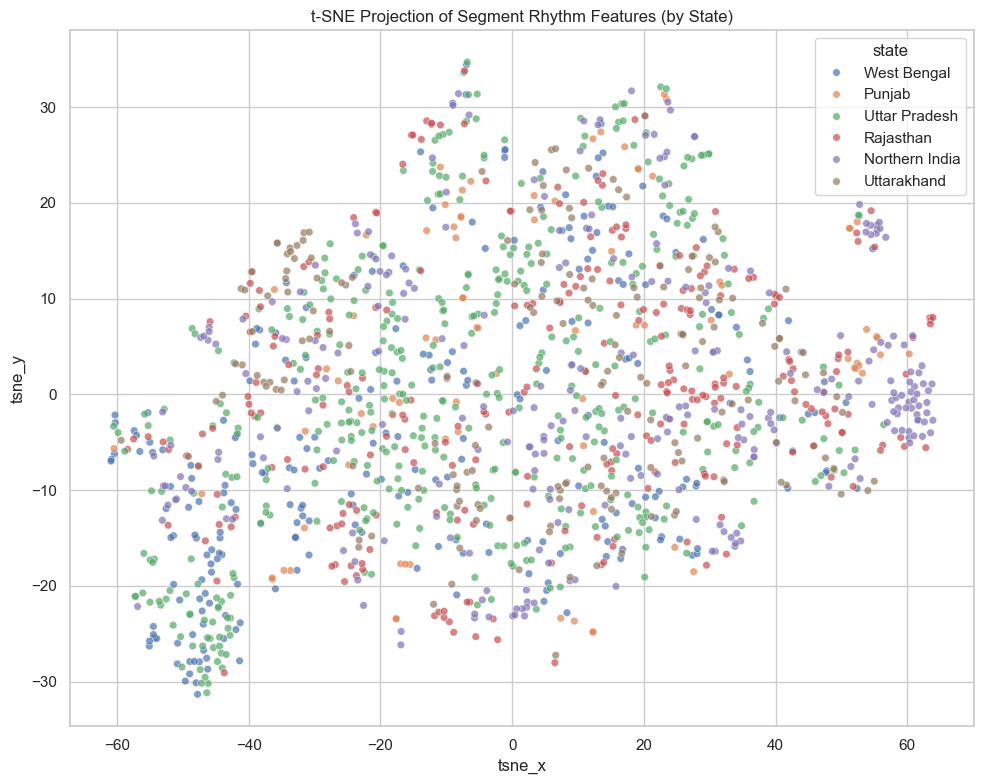

In [14]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x="tsne_x", y="tsne_y", hue="state", alpha=0.7, s=30)
plt.title("t-SNE Projection of Segment Rhythm Features (by State)")
plt.tight_layout()
plt.show()
